In [1]:
# ============================================
# Imports & basic config
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F


from torch.utils.data import random_split, ConcatDataset

from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv

import copy

# Use CPU (you installed CPU-only PyTorch)
device = torch.device("cpu")
print("Using device:", device)

# ====== CHANGE THIS IF DIFFERENT ======
RESULTS_ROOT = r"D:\my_projects\pmu-placement-gnn\results"
GNN_DATA_ROOT = os.path.join(RESULTS_ROOT, "gnn_dataset")
print("GNN_DATA_ROOT:", GNN_DATA_ROOT)





Using device: cpu
GNN_DATA_ROOT: D:\my_projects\pmu-placement-gnn\results\gnn_dataset


In [2]:
# %%
# ============================================
# Safe CSV writer (no overwrite unless you want it)
# - avoids PermissionError if open in Excel
# - can auto-make-unique if file already exists
# ============================================
import os, time

def safe_to_csv(df, path, index=False, make_unique_if_exists=False, **kwargs):
    """
    Saves df to CSV.

    If make_unique_if_exists=True and path already exists,
    appends a timestamp to create a new file instead of overwriting.

    If PermissionError occurs (Excel open), always saves to a timestamped filename.
    """
    path = os.path.abspath(path)
    os.makedirs(os.path.dirname(path), exist_ok=True)

    # Optional: avoid overwriting
    if make_unique_if_exists and os.path.exists(path):
        base, ext = os.path.splitext(path)
        ts = time.strftime("%Y%m%d_%H%M%S")
        path = f"{base}_{ts}{ext}"

    try:
        df.to_csv(path, index=index, **kwargs)
        print("Saved CSV:", path)
        return path
    except PermissionError:
        base, ext = os.path.splitext(path)
        ts = time.strftime("%Y%m%d_%H%M%S")
        alt = f"{base}_{ts}{ext}"
        df.to_csv(alt, index=index, **kwargs)
        print("[WARN] File locked, saved instead:", alt)
        return alt


In [3]:
# %%
# ============================================
# Coverage + diversity + PMU-rate penalties (better for IEEE57)
# ============================================
import torch
import torch.nn.functional as F

def _neighbors_list(edge_index, N):
    neighbors = [[] for _ in range(N)]
    src = edge_index[0].detach().cpu().tolist()
    dst = edge_index[1].detach().cpu().tolist()
    for u, v in zip(src, dst):
        if u == v:
            continue
        neighbors[u].append(v)
        neighbors[v].append(u)
    return neighbors

def coverage_penalty(batch, logits, lambda_cov=1.0):
    """
    Penalize probability of being unobserved:
      P(i unobserved) ≈ prod_{j in {i ∪ N(i)}} (1 - p_j)

    IMPORTANT: compute per-graph then mean, so big graphs don't dominate batches.
    """
    probs = F.softmax(logits, dim=-1)[:, 1]   # [N_total]
    one_minus = 1.0 - probs

    N = probs.size(0)
    neighbors = _neighbors_list(batch.edge_index, N)

    per_node_unobs = []
    for i in range(N):
        idxs = [i] + neighbors[i]
        idxs_t = torch.tensor(idxs, dtype=torch.long, device=probs.device)
        per_node_unobs.append(one_minus[idxs_t].prod())
    per_node_unobs = torch.stack(per_node_unobs)  # [N_total]

    # per-graph mean (batch.ptr marks graph boundaries)
    losses = []
    for g in range(batch.num_graphs):
        s = int(batch.ptr[g].item())
        e = int(batch.ptr[g + 1].item())
        if e > s:
            losses.append(per_node_unobs[s:e].mean())
    if not losses:
        return torch.tensor(0.0, device=probs.device)

    return lambda_cov * torch.stack(losses).mean()

def diversity_penalty(batch, logits, lambda_div=0.2):
    """
    Penalize adjacent PMUs: mean_{(u,v) in edges} p_u * p_v
    This reduces PMU clustering (very important for IEEE118 coverage).
    """
    probs = F.softmax(logits, dim=-1)[:, 1]
    ei = batch.edge_index

    # remove self loops
    mask = ei[0] != ei[1]
    u = ei[0][mask]
    v = ei[1][mask]

    # count each undirected edge once
    keep = u < v
    u = u[keep]
    v = v[keep]

    if u.numel() == 0:
        return torch.tensor(0.0, device=probs.device)

    return lambda_div * (probs[u] * probs[v]).mean()

def pmu_rate_penalty(batch, logits, lambda_rate=0.05):
    """
    Match average predicted PMU probability per-graph to label density.
    Improves calibration and helps ranking selection.
    """
    probs = F.softmax(logits, dim=-1)[:, 1]

    losses = []
    for g in range(batch.num_graphs):
        s = int(batch.ptr[g].item())
        e = int(batch.ptr[g + 1].item())
        if e <= s:
            continue
        target = batch.y[s:e].float().mean()
        pred   = probs[s:e].mean()
        losses.append((pred - target).pow(2))

    if not losses:
        return torch.tensor(0.0, device=probs.device)

    return lambda_rate * torch.stack(losses).mean()


In [4]:
# %%
# ============================================
# PMU GNN Dataset class (fixed paths + torch.load compatibility)
# ============================================
import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data, InMemoryDataset

class PMUGNNDataset(InMemoryDataset):
    def __init__(self, root, index_csv, transform=None, pre_transform=None):
        """
        root: dataset directory (folder that contains index.csv and 'samples/' folder)
        index_csv: full path to index.csv
        """
        self.index_csv = index_csv
        super().__init__(root, transform, pre_transform)

        # Load processed data (PyTorch version compatible)
        try:
            # Newer PyTorch supports weights_only
            self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)
        except TypeError:
            # Older PyTorch
            self.data, self.slices = torch.load(self.processed_paths[0])

    @property
    def raw_file_names(self):
        return [os.path.basename(self.index_csv)]

    @property
    def processed_file_names(self):
        return ["data.pt"]

    def download(self):
        pass

    def process(self):
        df = pd.read_csv(self.index_csv)

        # Folder that contains index.csv (e.g. ...\IEEE14)
        base_dir = os.path.dirname(self.index_csv)

        data_list = []
        for _, row in df.iterrows():
            npz_path = os.path.join(base_dir, row["file"])
            if not os.path.isfile(npz_path):
                raise FileNotFoundError(f"NPZ sample not found: {npz_path}")

            arr = np.load(npz_path, allow_pickle=True)

            x         = torch.tensor(arr["x"], dtype=torch.float32)
            edge_index= torch.tensor(arr["edge_index"], dtype=torch.long)
            edge_attr = torch.tensor(arr["edge_attr"], dtype=torch.float32)
            y         = torch.tensor(arr["y"], dtype=torch.long)
            graph_y   = torch.tensor(arr["graph_y"], dtype=torch.float32)
            scenario_type = str(arr["scenario_type"][0])

            data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
            data.graph_y = graph_y
            data.scenario_type = scenario_type

            data_list.append(data)

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])
        print(f"Processed {len(data_list)} samples into {self.processed_paths[0]}")


In [5]:
# %%
# ============================================
# MULTI-RUN DATASET PATHS + LOAD + SPLIT  (with SYSTEM_NAME fix)
# ============================================
import os
from torch.utils.data import random_split, ConcatDataset
from torch_geometric.loader import DataLoader

def load_run_dataset(system_dir):
    """
    system_dir: folder that contains index.csv and the samples/ subfolder.
    Example: D:\...\results\gnn_dataset\RUN_...\IEEE57
    """
    index_csv = os.path.join(system_dir, "index.csv")
    if not os.path.isfile(index_csv):
        raise FileNotFoundError(f"index.csv not found for dataset at: {system_dir}")
    return PMUGNNDataset(root=system_dir, index_csv=index_csv)

N1_DATASET_DIRS = [
    r"D:\my_projects\pmu-placement-gnn\results\gnn_dataset\RUN_20260104_204210_greedy_n1_57\IEEE57"
]

RANDOM_DATASET_DIRS = [
    # r"D:\my_projects\pmu-placement-gnn\results\gnn_dataset\RUN_...\IEEE14",
]

print("N-1 dataset dirs:")
for p in N1_DATASET_DIRS:
    print("  ", p)
print("Random-fault dataset dirs:")
for p in RANDOM_DATASET_DIRS:
    print("  ", p)

# Main system dir you use elsewhere
IEEE57_N1_DIR = N1_DATASET_DIRS[0]

# ✅ IMPORTANT: define this ONCE, early, and reuse everywhere
SYSTEM_NAME = os.path.basename(str(IEEE57_N1_DIR).rstrip("/\\")) or "SYSTEM"
print("SYSTEM_NAME:", SYSTEM_NAME)

# Load datasets
datasets = []

for path in N1_DATASET_DIRS:
    if not path:
        continue
    print(f"\n--- Loading N-1 dataset: {path} ---")
    ds = load_run_dataset(path)
    print("  Samples:", len(ds))
    datasets.append(ds)

for path in RANDOM_DATASET_DIRS:
    if not path:
        continue
    print(f"\n--- Loading RANDOM-fault dataset: {path} ---")
    try:
        ds = load_run_dataset(path)
        print("  Samples:", len(ds))
        datasets.append(ds)
    except FileNotFoundError as e:
        print("[WARN] Random dataset not found, ignoring:", e)

if not datasets:
    raise RuntimeError("No datasets loaded. Check your paths in N1_DATASET_DIRS and RANDOM_DATASET_DIRS.")

# Merge
full_dataset = datasets[0] if len(datasets) == 1 else ConcatDataset(datasets)
print("\nTotal graphs in full_dataset:", len(full_dataset))

# 80/20 split
num_samples = len(full_dataset)
num_train = int(0.8 * num_samples)
num_val   = num_samples - num_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [num_train, num_val],
    generator=torch.Generator().manual_seed(42)
)

print("Train graphs:", len(train_dataset))
print("Val graphs  :", len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)


N-1 dataset dirs:
   D:\my_projects\pmu-placement-gnn\results\gnn_dataset\RUN_20260104_204210_greedy_n1_57\IEEE57
Random-fault dataset dirs:
SYSTEM_NAME: IEEE57

--- Loading N-1 dataset: D:\my_projects\pmu-placement-gnn\results\gnn_dataset\RUN_20260104_204210_greedy_n1_57\IEEE57 ---


Processing...


Processed 81 samples into D:\my_projects\pmu-placement-gnn\results\gnn_dataset\RUN_20260104_204210_greedy_n1_57\IEEE57\processed\data.pt
  Samples: 81

Total graphs in full_dataset: 81
Train graphs: 64
Val graphs  : 17


Done!


In [6]:
# %%
# ============================================
# GNN run output folder (unique per execution)
# ============================================
import os
import datetime

# Ensure SYSTEM_NAME exists
if "SYSTEM_NAME" not in globals():
    if "IEEE57_N1_DIR" in globals():
        SYSTEM_NAME = os.path.basename(str(IEEE57_N1_DIR).rstrip("/\\")) or "SYSTEM"
    else:
        SYSTEM_NAME = "SYSTEM"

GNN_RUN_ID = datetime.datetime.now().strftime("GNN_%Y%m%d_%H%M%S")

# All GNN outputs for this run go here:
# results/metrics_gnn/<SYSTEM_NAME>/<GNN_RUN_ID>/
METRICS_GNN_DIR = os.path.join(RESULTS_ROOT, "metrics_gnn", SYSTEM_NAME, GNN_RUN_ID)
os.makedirs(METRICS_GNN_DIR, exist_ok=True)

print("SYSTEM_NAME     :", SYSTEM_NAME)
print("GNN_RUN_ID      :", GNN_RUN_ID)
print("METRICS_GNN_DIR :", METRICS_GNN_DIR)


SYSTEM_NAME     : IEEE57
GNN_RUN_ID      : GNN_20260105_023354
METRICS_GNN_DIR : D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354


In [7]:
# ============================================
# Force the intact sample into the TRAINING set (recommended for stability)
# ============================================
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader

# Find intact index
intact_indices = [
    i for i in range(len(full_dataset))
    if getattr(full_dataset[i], "scenario_type", None) == "intact"
]

if intact_indices:
    intact_idx = intact_indices[0]
    print("Intact sample index in full_dataset:", intact_idx)
else:
    intact_idx = None
    print("No intact sample found in full_dataset.")

all_idx = list(range(len(full_dataset)))
if intact_idx is not None:
    all_idx.remove(intact_idx)

# 80/20 split on remaining graphs
split = int(0.8 * len(all_idx))
train_idx = all_idx[:split]
val_idx   = all_idx[split:]

# force intact into TRAIN
if intact_idx is not None:
    train_idx = [intact_idx] + train_idx

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)

print("Rebuilt splits with intact sample forced into TRAIN.")
print("Train size:", len(train_dataset), "| Val size:", len(val_dataset))
print("Training contains intact:", (intact_idx in train_idx) if intact_idx is not None else False)



BATCH_SIZE = 1 if "57" in SYSTEM_NAME else 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)


Intact sample index in full_dataset: 0
Rebuilt splits with intact sample forced into TRAIN.
Train size: 65 | Val size: 16
Training contains intact: True


In [8]:
# ============================================
# Compute class weights for imbalance (0=no PMU, 1=PMU)
# ============================================
from collections import Counter

all_labels = []

# full_dataset exists from the loading cell
for i in range(len(full_dataset)):
    y_i = full_dataset[i].y
    all_labels.extend(y_i.cpu().tolist())

counts = Counter(all_labels)
num_0 = counts.get(0, 1)
num_1 = counts.get(1, 1)

print("Label counts:", counts)

# Weight class 1 (PMU) higher so the model is punished more
w0 = 1.0
w1 = num_0 / num_1  # e.g. if 0:1 ratio is 10:1, then w1=10

class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)
print("Class weights:", class_weights)


Label counts: Counter({0: 3143, 1: 1474})
Class weights: tensor([1.0000, 2.1323])


In [9]:
# ============================================
# GNN model definition (simple GCN)
# ============================================
class PMUGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)  # logits per node
        return x

# Get feature dimension from one sample
sample = full_dataset[0] if isinstance(full_dataset, PMUGNNDataset) else full_dataset[0]
in_channels = sample.x.size(1)
print("Node feature dimension:", in_channels)

model = PMUGCN(in_channels=in_channels, hidden_channels=128, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)




Node feature dimension: 5


In [10]:
# %%
# ============================================
# Training and evaluation functions (with better losses for IEEE118)
# ============================================
def train_one_epoch(
    model, loader, optimizer, criterion, device,
    lambda_cov=1.0,
    lambda_div=0.2,
    lambda_rate=0.05
):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index)

        ce_loss   = criterion(out, batch.y)
        cov_loss  = coverage_penalty(batch, out, lambda_cov=lambda_cov)
        div_loss  = diversity_penalty(batch, out, lambda_div=lambda_div)
        rate_loss = pmu_rate_penalty(batch, out, lambda_rate=lambda_rate)

        loss = ce_loss + cov_loss + div_loss + rate_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_nodes
        preds = out.argmax(dim=-1)
        total_correct += (preds == batch.y).sum().item()
        total_nodes += batch.num_nodes

    avg_loss = total_loss / max(total_nodes, 1)
    acc = total_correct / max(total_nodes, 1)
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # keep validation as CE only (stable comparison)
        loss = criterion(out, batch.y)

        total_loss += loss.item() * batch.num_nodes
        preds = out.argmax(dim=-1)
        total_correct += (preds == batch.y).sum().item()
        total_nodes += batch.num_nodes

    if total_nodes == 0:
        return 0.0, 0.0

    return total_loss / total_nodes, total_correct / total_nodes


In [11]:
# %%
# ============================================
# Training loop (store curves)
# ============================================
num_epochs = 150  # you can increase later

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

best_val_acc = 0.0
best_state_dict = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        lambda_cov=0.3,    # <--- coverage penalty weight
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

print("\nBest validation accuracy:", best_val_acc)
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("Loaded best model state (based on val acc).")


Epoch 01 | Train loss: 1.1530, acc: 0.4920 | Val loss: 0.6960, acc: 0.6831
Epoch 02 | Train loss: 0.7724, acc: 0.5541 | Val loss: 0.6917, acc: 0.6831
Epoch 03 | Train loss: 0.7707, acc: 0.5700 | Val loss: 0.6942, acc: 0.6831
Epoch 04 | Train loss: 0.7710, acc: 0.5568 | Val loss: 0.6893, acc: 0.5197
Epoch 05 | Train loss: 0.7715, acc: 0.5530 | Val loss: 0.6890, acc: 0.5164
Epoch 06 | Train loss: 0.7717, acc: 0.5422 | Val loss: 0.6885, acc: 0.5998
Epoch 07 | Train loss: 0.7697, acc: 0.5584 | Val loss: 0.6956, acc: 0.3728
Epoch 08 | Train loss: 0.7710, acc: 0.5401 | Val loss: 0.6975, acc: 0.7007
Epoch 09 | Train loss: 0.7679, acc: 0.5447 | Val loss: 0.6848, acc: 0.5373
Epoch 10 | Train loss: 0.7746, acc: 0.5336 | Val loss: 0.6870, acc: 0.5143
Epoch 11 | Train loss: 0.7664, acc: 0.5412 | Val loss: 0.6873, acc: 0.5965
Epoch 12 | Train loss: 0.7690, acc: 0.5433 | Val loss: 0.7014, acc: 0.3860
Epoch 13 | Train loss: 0.7699, acc: 0.5409 | Val loss: 0.6851, acc: 0.4792
Epoch 14 | Train loss: 0.

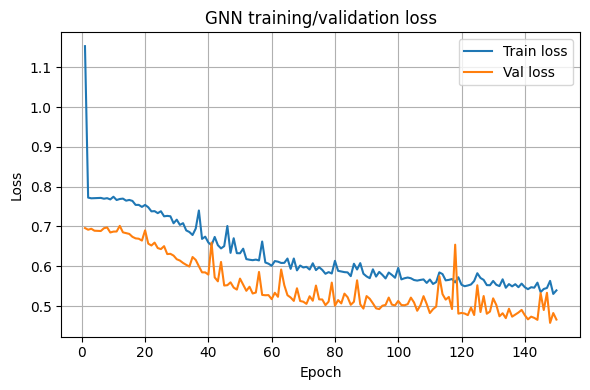

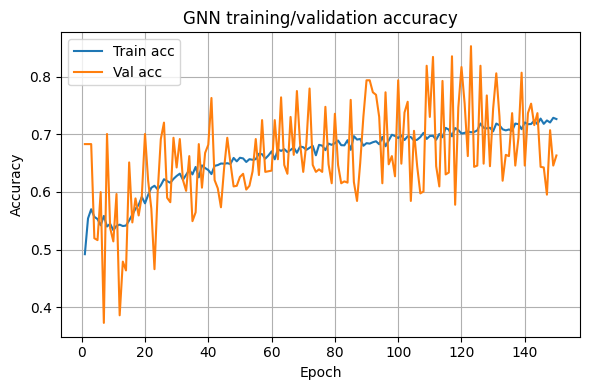

In [12]:
# ============================================
# Plot training / validation curves
# ============================================
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN training/validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs, label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GNN training/validation accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
# %%
# ============================================
# Node-level accuracy: overall, intact, faulted  + SAVE CSV (timestamped)
# - Evaluates "val" normally
# - Evaluates intact separately from full_dataset so it's never missing
# ============================================
import os, datetime
import numpy as np
import pandas as pd
import torch

# --- stable names ---
SYSTEM_NAME = globals().get("SYSTEM_NAME", None) or os.path.basename(str(IEEE57_N1_DIR).rstrip("/\\")) or "SYSTEM"

# One ID for this metrics dump (so you see a NEW file each run)
GNN_RUN_ID = globals().get("GNN_RUN_ID", None)
if GNN_RUN_ID is None:
    GNN_RUN_ID = datetime.datetime.now().strftime("GNN_%Y%m%d_%H%M%S")
    globals()["GNN_RUN_ID"] = GNN_RUN_ID

@torch.no_grad()
def node_acc_on_graphs(model, graphs, device):
    model.eval()
    total_correct, total_nodes = 0, 0
    for g in graphs:
        g = g.to(device)
        out = model(g.x, g.edge_index)
        pred = out.argmax(dim=-1)
        total_correct += (pred == g.y).sum().item()
        total_nodes   += g.num_nodes
    return (total_correct / total_nodes) if total_nodes > 0 else np.nan, int(total_nodes)

# ---- build lists of graphs ----
# (A) validation graphs
val_graphs = [val_dataset[i] for i in range(len(val_dataset))]

# (B) intact graphs from the ENTIRE dataset (so intact is never "missing")
all_intact = [full_dataset[i] for i in range(len(full_dataset))
              if getattr(full_dataset[i], "scenario_type", None) == "intact"]

# (C) faulted graphs from validation (typical "robustness" eval)
val_faulted = [g for g in val_graphs if getattr(g, "scenario_type", None) == "faulted"]

acc_val,   nodes_val   = node_acc_on_graphs(model, val_graphs, device)
acc_int,   nodes_int   = node_acc_on_graphs(model, all_intact, device)
acc_fault, nodes_fault = node_acc_on_graphs(model, val_faulted, device)

df_metrics = pd.DataFrame([{
    "system": SYSTEM_NAME,
    "gnn_run_id": GNN_RUN_ID,

    "val_node_acc_%":   acc_val   * 100.0 if np.isfinite(acc_val)   else np.nan,
    "intact_node_acc_%":acc_int   * 100.0 if np.isfinite(acc_int)   else np.nan,
    "faulted_node_acc_%":acc_fault* 100.0 if np.isfinite(acc_fault) else np.nan,

    "val_nodes_total": nodes_val,
    "val_nodes_faulted": nodes_fault,
    "full_nodes_intact": nodes_int,

    "val_graphs_total": int(len(val_graphs)),
    "val_graphs_faulted": int(len(val_faulted)),
    "full_graphs_intact": int(len(all_intact)),
}])

display(df_metrics)

out_dir = os.path.join(RESULTS_ROOT, "metrics_gnn")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"gnn_val_metrics_{SYSTEM_NAME}_{GNN_RUN_ID}.csv")

safe_to_csv(df_metrics, out_path, index=False)
print("Saved:", out_path)


,system,gnn_run_id,val_node_acc_%,intact_node_acc_%,faulted_node_acc_%,val_nodes_total,val_nodes_faulted,full_nodes_intact,val_graphs_total,val_graphs_faulted,full_graphs_intact
0,IEEE57,GNN_20260105_023354,85.307018,87.719298,85.307018,912,912,57,16,16,1


Saved CSV: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\gnn_val_metrics_IEEE57_GNN_20260105_023354.csv
Saved: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\gnn_val_metrics_IEEE57_GNN_20260105_023354.csv


In [14]:
# ============================================
# Example: inspect one validation graph
# ============================================
example_graph = val_dataset[0]
example_graph = example_graph.to(device)

model.eval()
with torch.no_grad():
    out = model(example_graph.x, example_graph.edge_index)
    preds = out.argmax(dim=-1)  # 0/1 per node

pred_pmu_nodes = (preds == 1).nonzero(as_tuple=True)[0].cpu().numpy().tolist()
true_pmu_nodes = (example_graph.y == 1).nonzero(as_tuple=True)[0].cpu().numpy().tolist()

print("Scenario type:", example_graph.scenario_type)
print("Predicted PMU nodes (indices):", pred_pmu_nodes)
print("True PMU nodes (indices):     ", true_pmu_nodes)


Scenario type: faulted
Predicted PMU nodes (indices): [0, 3, 8, 10, 14, 23, 36, 37, 45, 49, 52, 55, 56]
True PMU nodes (indices):      [0, 3, 8, 10, 14, 19, 23, 24, 25, 28, 31, 34, 36, 37, 45, 49, 52, 55]


Detected system name for figures: IEEE57
Saving GNN figures to: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701
Saved PNG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023701_gnn_loss_curves_IEEE57.png
Saved SVG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023701_gnn_loss_curves_IEEE57.svg
Running Inkscape for EMF export...
Saved EMF: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023701_gnn_loss_curves_IEEE57.emf


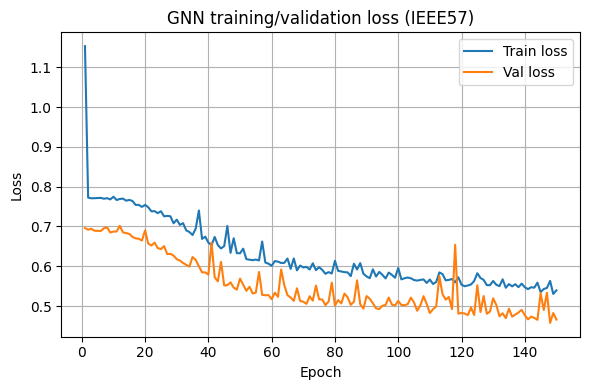

Saved PNG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023705_gnn_acc_curves_IEEE57.png
Saved SVG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023705_gnn_acc_curves_IEEE57.svg
Running Inkscape for EMF export...
Saved EMF: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023705_gnn_acc_curves_IEEE57.emf


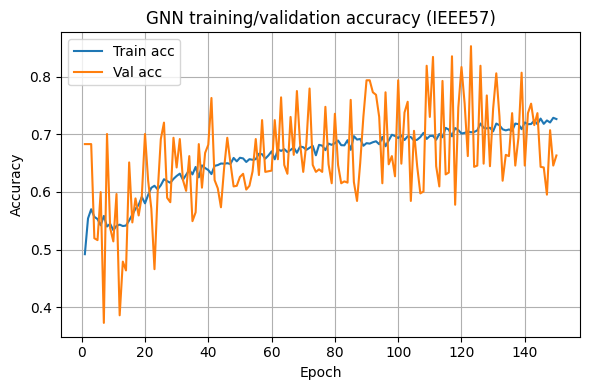

In [15]:
# ============================================
# Save GNN training curves as PNG/SVG/EMF (auto system name)
# ============================================
import os, datetime, subprocess

# Try to infer the system name from the N-1 dataset directory
try:
    dataset_dir_for_name = IEEE57_N1_DIR   # this is what you set in the dataset paths cell
except NameError:
    # Fallback: just use GNN_DATA_ROOT if the variable name changes
    dataset_dir_for_name = GNN_DATA_ROOT

# System name = last folder name of the dataset directory (e.g. "IEEE14", "IEEE118", ...)
system_name = os.path.basename(str(dataset_dir_for_name).rstrip("/\\")) or "SYSTEM"
print("Detected system name for figures:", system_name)

# Create a unique subfolder per GNN run (timestamp-based run id)
run_id = datetime.datetime.now().strftime("GNN_%Y%m%d_%H%M%S")

# Folder for GNN figures: results/figures_gnn/<system_name>/<run_id>
gnn_fig_dir = os.path.join(RESULTS_ROOT, "figures_gnn", system_name, run_id)
os.makedirs(gnn_fig_dir, exist_ok=True)
print("Saving GNN figures to:", gnn_fig_dir)


# Inkscape config (for EMF export)
ENABLE_EMF_EXPORT = True                                      # set False if you only want PNG + SVG
INKSCAPE_EXE = r"D:\Programs\inkscape\bin\inkscape.exe"  # <-- adjust if needed


def save_gnn_fig(fig, kind):
    """
    Save a Matplotlib figure as:
      - PNG
      - SVG
      - (optionally) EMF via Inkscape

    Filenames include:
      timestamp, 'gnn', kind, and system_name
    """
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    base = f"{ts}_gnn_{kind}_{system_name}"

    png_path = os.path.join(gnn_fig_dir, base + ".png")
    svg_path = os.path.join(gnn_fig_dir, base + ".svg")
    emf_path = os.path.join(gnn_fig_dir, base + ".emf")

    # 1) PNG
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    print("Saved PNG:", png_path)

    # 2) SVG
    try:
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        print("Saved SVG:", svg_path)
    except Exception as e:
        print("[WARN] SVG save failed:", e)

    # 3) EMF via Inkscape 
    if ENABLE_EMF_EXPORT:
        try:
            if not os.path.isfile(INKSCAPE_EXE):
                raise FileNotFoundError(f"Inkscape not found at: {INKSCAPE_EXE}")

            cmd = [
                INKSCAPE_EXE,
                svg_path,
                "--export-type=emf",
                f"--export-filename={emf_path}",
            ]
            print("Running Inkscape for EMF export...")
            subprocess.run(cmd, check=True)
            print("Saved EMF:", emf_path)
        except Exception as e:
            print("[WARN] EMF export failed:", e)

    return png_path


# ============================================
# Re-plot and save loss & accuracy curves
# ============================================
epochs = range(1, num_epochs + 1)

# ---- Loss curves ----
fig1 = plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"GNN training/validation loss ({system_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_gnn_fig(fig1, "loss_curves")
plt.show()

# ---- Accuracy curves ----
fig2 = plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs,   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"GNN training/validation accuracy ({system_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_gnn_fig(fig2, "acc_curves")
plt.show()


In [16]:
# ============================================
# Save best trained GNN model to disk
# ============================================
import time

# System name from dataset path (e.g. "IEEE14", "IEEE57", ...)
system_name = os.path.basename(IEEE57_N1_DIR)

# Folder where all GNN models for this system will be stored
model_root = os.path.join(RESULTS_ROOT, "gnn_models", system_name)
os.makedirs(model_root, exist_ok=True)

# A short tag to remember what this model is
# (change this if you train on something else, e.g. "n1", "random", "n1_v2", etc.)
MODEL_TAG = "n1"

# Add timestamp so each training run is a different file
timestamp = time.strftime("%Y%m%d_%H%M%S")
model_filename = f"pmu_gnn_{MODEL_TAG}_{timestamp}.pth"
model_path = os.path.join(model_root, model_filename)

# If you used best_state_dict during training, save that.
# Otherwise, fall back to current model.state_dict()
if "best_state_dict" in globals() and best_state_dict is not None:
    state_to_save = best_state_dict
    print("Saving best_state_dict (best validation model).")
else:
    state_to_save = model.state_dict()
    print("best_state_dict not found; saving current model.state_dict().")

# Save weights + some useful info together
checkpoint = {
    "state_dict": state_to_save,
    "in_channels": in_channels,
    "hidden_channels": 128,   # change here if you changed the model
    "out_channels": 2,
    "system_name": system_name,
    "dataset_dir": IEEE57_N1_DIR,
    "tag": MODEL_TAG,
    "saved_at": timestamp,
}

torch.save(checkpoint, model_path)

print("\nSaved GNN checkpoint to:")
print("  ", model_path)
print("You can later reload this file and reuse the model.")


Saving best_state_dict (best validation model).

Saved GNN checkpoint to:
   D:\my_projects\pmu-placement-gnn\results\gnn_models\IEEE57\pmu_gnn_n1_20260105_023708.pth
You can later reload this file and reuse the model.


In [17]:
# %%
# ============================================
# Load a saved GNN model checkpoint (auto-latest)  [FIXED for IEEE118]
# ============================================
import os
import torch

# ✅ FIX: use IEEE118_N1_DIR (NOT IEEE14_N1_DIR)
system_name = os.path.basename(str(IEEE57_N1_DIR).rstrip("/\\"))
model_root  = os.path.join(RESULTS_ROOT, "gnn_models", system_name)

print("Looking for checkpoints in:", model_root)

if not os.path.isdir(model_root):
    raise FileNotFoundError(f"No model directory found for system '{system_name}': {model_root}")

model_files = [
    os.path.join(model_root, f)
    for f in os.listdir(model_root)
    if f.lower().endswith(".pth")
]

if not model_files:
    raise FileNotFoundError(f"No .pth checkpoints found in: {model_root}")

ckpt_path = max(model_files, key=os.path.getmtime)

checkpoint = torch.load(ckpt_path, map_location=device)
print("\nLoaded checkpoint from:", ckpt_path)
print("  system_name:", checkpoint.get("system_name"))
print("  tag        :", checkpoint.get("tag"))
print("  saved_at   :", checkpoint.get("saved_at"))

in_channels_loaded  = checkpoint.get("in_channels")
hidden_channels     = checkpoint.get("hidden_channels", 64)
out_channels_loaded = checkpoint.get("out_channels", 2)

model = PMUGCN(
    in_channels=in_channels_loaded,
    hidden_channels=hidden_channels,
    out_channels=out_channels_loaded,
).to(device)

model.load_state_dict(checkpoint["state_dict"])
model.eval()

print("\nModel is loaded and ready for evaluation / testing.")


Looking for checkpoints in: D:\my_projects\pmu-placement-gnn\results\gnn_models\IEEE57

Loaded checkpoint from: D:\my_projects\pmu-placement-gnn\results\gnn_models\IEEE57\pmu_gnn_n1_20260105_023708.pth
  system_name: IEEE57
  tag        : n1
  saved_at   : 20260105_023708

Model is loaded and ready for evaluation / testing.


In [18]:
# %%
# ============================================
# Coverage-aware decoding (BEST coverage boost for IEEE118)
# ============================================
import numpy as np
import torch
import torch.nn.functional as F

def build_neighbors(edge_index, n):
    ei = edge_index.detach().cpu().numpy()
    neigh = [set() for _ in range(n)]
    for u, v in ei.T:
        u = int(u); v = int(v)
        if u == v:
            continue
        neigh[u].add(v)
        neigh[v].add(u)
    return neigh

@torch.no_grad()
def gnn_select_pmus_coverage_aware(data, K, topM=None):
    """
    Select K nodes guided by GNN probabilities but maximizing coverage gain.
    - Compute probs
    - Restrict candidates to topM by prob (optional)
    - Greedy select by marginal observed-node gain; tie-break by prob
    """
    data = data.to(device)
    logits = model(data.x, data.edge_index)
    probs  = F.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()

    N = data.num_nodes
    neigh = build_neighbors(data.edge_index, N)

    if topM is None:
        candidates = list(range(N))
    else:
        topM = int(min(N, topM))
        candidates = np.argsort(-probs)[:topM].tolist()

    selected = []
    observed = set()

    for _ in range(int(K)):
        best = None
        best_gain = -1
        best_prob = -1.0

        for n in candidates:
            if n in selected:
                continue
            new_obs = {n} | neigh[n]
            gain = len(new_obs - observed)

            if (gain > best_gain) or (gain == best_gain and probs[n] > best_prob):
                best = n
                best_gain = gain
                best_prob = probs[n]

        if best is None:
            break

        selected.append(best)
        observed |= ({best} | neigh[best])

    return selected


In [19]:
# %%
# ============================================
# Debug + SAVE: coverage/robustness table (Greedy vs GNN top-K)
# Saves into per-run folder with unique filename
# ============================================
import os
import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn.functional as F

# --------- Coverage-aware decoding helper (define once if missing) ----------
if "gnn_select_pmus_coverage_aware" not in globals():
    @torch.no_grad()
    def gnn_select_pmus_coverage_aware(data, K, topM=80):
        """
        Coverage-aware decode:
          1) compute p(PMU) from GNN
          2) take topM candidates by probability
          3) greedily pick K nodes to maximize 1-hop coverage (self + neighbors)
        Uses global `model` and `device`.
        """
        data = data.to(device)
        model.eval()

        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits, dim=-1)[:, 1]  # p(PMU)

        N = int(data.num_nodes)
        M = int(min(max(1, topM), N))
        cand = torch.topk(probs, k=M, largest=True).indices.cpu().numpy().tolist()

        # build undirected neighbor sets
        neigh = [set() for _ in range(N)]
        ei = data.edge_index.cpu().numpy()
        for u, v in ei.T:
            u = int(u); v = int(v)
            if u == v:
                continue
            neigh[u].add(v)
            neigh[v].add(u)

        # precompute each candidate's covered set = {i} ∪ N(i)
        cover_sets = {}
        for c in cand:
            cover_sets[c] = set([c]) | neigh[c]

        chosen = []
        covered = set()

        # greedy maximize marginal gain; tie-break by higher prob
        probs_cpu = probs.detach().cpu().numpy()
        remaining = set(cand)

        for _ in range(int(K)):
            best = None
            best_gain = -1
            best_prob = -1.0

            for c in remaining:
                gain = len(cover_sets[c] - covered)
                p = float(probs_cpu[c])
                if (gain > best_gain) or (gain == best_gain and p > best_prob):
                    best_gain = gain
                    best_prob = p
                    best = c

            if best is None:
                break

            chosen.append(best)
            covered |= cover_sets[best]
            remaining.remove(best)

        return chosen

# ---------------------------------------------------------------------------

def pyg_to_nx_graph(data):
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    edge_index = data.edge_index.cpu().numpy()
    for u, v in edge_index.T:
        u = int(u); v = int(v)
        if u != v:
            G.add_edge(u, v)
    return G

def observed_nodes_simple(G, pmus):
    obs = set(pmus)
    for n in pmus:
        obs.update(G.neighbors(n))
    return obs

def greedy_pmu_placement_simple(G):
    all_nodes = set(G.nodes())
    pmus = []
    observed = set()
    while observed != all_nodes:
        best_node, best_gain = None, -1
        for n in all_nodes - set(pmus):
            gain = len(observed_nodes_simple(G, [n]) - observed)
            if gain > best_gain:
                best_gain, best_node = gain, n
        pmus.append(best_node)
        observed.update(observed_nodes_simple(G, [best_node]))
    return pmus

# ✅ REPLACED FUNCTION (6A)
@torch.no_grad()
def gnn_topk_pmus(data, K):
    # For IEEE118: restrict to top candidates then maximize coverage
    return gnn_select_pmus_coverage_aware(data, K, topM=max(2*K, 80))

def coverage_percent(G, pmus):
    obs = observed_nodes_simple(G, pmus)
    return 100.0 * len(obs) / G.number_of_nodes()

# -------- choose dataset --------
eval_dataset = val_dataset  # or train_dataset / full_dataset

cov_greedy_list = []
cov_gnn_list    = []
K_list          = []
types_list      = []

for i in range(len(eval_dataset)):
    data = eval_dataset[i]
    types_list.append(getattr(data, "scenario_type", "unknown"))

    G = pyg_to_nx_graph(data)

    pmus_greedy = greedy_pmu_placement_simple(G)
    K = len(pmus_greedy)

    pmus_gnn = gnn_topk_pmus(data, K)

    cov_greedy = coverage_percent(G, pmus_greedy)
    cov_gnn    = coverage_percent(G, pmus_gnn)

    cov_greedy_list.append(cov_greedy)
    cov_gnn_list.append(cov_gnn)
    K_list.append(K)

    print(f"Graph {i:02d} | type={types_list[-1]:7s} | K={K} | Greedy cov={cov_greedy:.1f}% | GNN cov={cov_gnn:.1f}%")

if not cov_greedy_list:
    raise RuntimeError("eval_dataset is empty; nothing to evaluate.")

system_name_local = SYSTEM_NAME if "SYSTEM_NAME" in globals() else "SYSTEM"

gnn_cov_table = pd.DataFrame([{
    "system": system_name_local,
    "dataset_used": "val_dataset",
    "num_graphs": int(len(cov_gnn_list)),
    "avg_K": float(np.mean(K_list)),
    "avg_greedy_coverage_%": float(np.mean(cov_greedy_list)),
    "avg_gnn_coverage_%": float(np.mean(cov_gnn_list)),
    "greedy_robustness_%": float(np.mean(np.array(cov_greedy_list) >= (100.0 - 1e-9)) * 100.0),
    "gnn_robustness_%": float(np.mean(np.array(cov_gnn_list)    >= (100.0 - 1e-9)) * 100.0),
    "num_intact_graphs_in_eval": int(sum(t == "intact" for t in types_list)),
    "num_faulted_graphs_in_eval": int(sum(t == "faulted" for t in types_list)),
}])

display(gnn_cov_table)

# -------- save (per-run folder + unique name) --------
out_dir = METRICS_GNN_DIR if "METRICS_GNN_DIR" in globals() else os.path.join(RESULTS_ROOT, "metrics_gnn")
os.makedirs(out_dir, exist_ok=True)

fname = f"gnn_coverage_metrics_{system_name_local}_{GNN_RUN_ID}.csv" if "GNN_RUN_ID" in globals() else f"gnn_coverage_metrics_{system_name_local}.csv"
out_path = os.path.join(out_dir, fname)

safe_to_csv(gnn_cov_table, out_path, index=False)
print("Saved coverage metrics CSV to:", out_path)


Graph 00 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 01 | type=faulted | K=19 | Greedy cov=100.0% | GNN cov=100.0%
Graph 02 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 03 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 04 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 05 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 06 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 07 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 08 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 09 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 10 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 11 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 12 | type=faulted | K=18 | Greedy cov=100.0% | GNN cov=100.0%
Graph 13 | type=faulted | K=17 | Greedy cov=100.0% | GNN cov=98.2%
Graph 14 | type=faulted | K=18 | Greedy cov=100.0

,system,dataset_used,num_graphs,avg_K,avg_greedy_coverage_%,avg_gnn_coverage_%,greedy_robustness_%,gnn_robustness_%,num_intact_graphs_in_eval,num_faulted_graphs_in_eval
0,IEEE57,val_dataset,16,18.0625,100.0,99.890351,100.0,93.75,0,16


Saved CSV: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354\gnn_coverage_metrics_IEEE57_GNN_20260105_023354.csv
Saved coverage metrics CSV to: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354\gnn_coverage_metrics_IEEE57_GNN_20260105_023354.csv


In [20]:
# %%
# ============================================
# Coverage + robustness table (Greedy labels vs GNN top-K) + SAVE CSV
# Default evaluates ALL FAULTED graphs in full_dataset (recommended for comparison)
# ============================================
import os, datetime
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

SYSTEM_NAME = globals().get("SYSTEM_NAME", None) or os.path.basename(str(IEEE57_N1_DIR).rstrip("/\\")) or "SYSTEM"
GNN_RUN_ID  = globals().get("GNN_RUN_ID", None)
if GNN_RUN_ID is None:
    GNN_RUN_ID = datetime.datetime.now().strftime("GNN_%Y%m%d_%H%M%S")
    globals()["GNN_RUN_ID"] = GNN_RUN_ID

# --------- Coverage-aware decoding helper (define once if missing) ----------
if "gnn_select_pmus_coverage_aware" not in globals():
    @torch.no_grad()
    def gnn_select_pmus_coverage_aware(data, K, topM=80):
        data = data.to(device)
        model.eval()

        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits, dim=-1)[:, 1]  # p(PMU)

        N = int(data.num_nodes)
        M = int(min(max(1, topM), N))
        cand = torch.topk(probs, k=M, largest=True).indices.cpu().numpy().tolist()

        neigh = [set() for _ in range(N)]
        ei = data.edge_index.cpu().numpy()
        for u, v in ei.T:
            u = int(u); v = int(v)
            if u == v:
                continue
            neigh[u].add(v)
            neigh[v].add(u)

        cover_sets = {c: (set([c]) | neigh[c]) for c in cand}
        probs_cpu = probs.detach().cpu().numpy()

        chosen = []
        covered = set()
        remaining = set(cand)

        for _ in range(int(K)):
            best = None
            best_gain = -1
            best_prob = -1.0
            for c in remaining:
                gain = len(cover_sets[c] - covered)
                p = float(probs_cpu[c])
                if (gain > best_gain) or (gain == best_gain and p > best_prob):
                    best_gain = gain
                    best_prob = p
                    best = c
            if best is None:
                break
            chosen.append(best)
            covered |= cover_sets[best]
            remaining.remove(best)

        return chosen

# ---------------------------------------------------------------------------

def build_neighbors(edge_index, n):
    ei = edge_index.cpu().numpy()
    neigh = [set() for _ in range(n)]
    for u, v in ei.T:
        u = int(u); v = int(v)
        if u == v:
            continue
        neigh[u].add(v)
        neigh[v].add(u)
    return neigh

def coverage_from_neighbors(neigh, pmus):
    obs = set(pmus)
    for p in pmus:
        obs |= neigh[p]
    return 100.0 * len(obs) / len(neigh)

def pmus_from_label_y(data):
    return (data.y == 1).nonzero(as_tuple=True)[0].cpu().numpy().tolist()

# ✅ REPLACED FUNCTION (6B)
@torch.no_grad()
def gnn_topk_from_probs(data, K):
    return gnn_select_pmus_coverage_aware(data, K, topM=max(2*K, 80))

# ---- choose evaluation set ----
EVAL_MODE = "full_faulted"  # options: "val_faulted", "full_faulted"

if EVAL_MODE == "val_faulted":
    graphs = [val_dataset[i] for i in range(len(val_dataset))
              if getattr(val_dataset[i], "scenario_type", None) == "faulted"]
    dataset_used = "val_dataset (faulted only)"
else:
    graphs = [full_dataset[i] for i in range(len(full_dataset))
              if getattr(full_dataset[i], "scenario_type", None) == "faulted"]
    dataset_used = "full_dataset (faulted only)"

if not graphs:
    raise RuntimeError(f"No graphs selected for EVAL_MODE={EVAL_MODE}. Check scenario_type labels.")

model.eval()

cov_greedy, cov_gnn, K_list = [], [], []

for g in graphs:
    neigh = build_neighbors(g.edge_index, g.num_nodes)

    pmus_greedy = pmus_from_label_y(g)        # ✅ greedy labels
    K = int(len(pmus_greedy))
    pmus_gnn = gnn_topk_from_probs(g, K)      # ✅ coverage-aware decode

    cov_greedy.append(coverage_from_neighbors(neigh, pmus_greedy))
    cov_gnn.append(coverage_from_neighbors(neigh, pmus_gnn))
    K_list.append(K)

cov_greedy = np.array(cov_greedy, dtype=float)
cov_gnn    = np.array(cov_gnn, dtype=float)

df_cov = pd.DataFrame([{
    "system": SYSTEM_NAME,
    "gnn_run_id": GNN_RUN_ID,
    "dataset_used": dataset_used,

    "num_graphs": int(len(graphs)),
    "avg_K": float(np.mean(K_list)),

    "avg_greedy_coverage_%": float(np.mean(cov_greedy)),
    "avg_gnn_coverage_%": float(np.mean(cov_gnn)),

    "greedy_robustness_%": float(np.mean(cov_greedy >= (100.0 - 1e-9)) * 100.0),
    "gnn_robustness_%": float(np.mean(cov_gnn    >= (100.0 - 1e-9)) * 100.0),
}])

display(df_cov)

out_dir = os.path.join(RESULTS_ROOT, "metrics_gnn")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"gnn_coverage_metrics_{SYSTEM_NAME}_{GNN_RUN_ID}.csv")

safe_to_csv(df_cov, out_path, index=False)
print("Saved:", out_path)


,system,gnn_run_id,dataset_used,num_graphs,avg_K,avg_greedy_coverage_%,avg_gnn_coverage_%,greedy_robustness_%,gnn_robustness_%
0,IEEE57,GNN_20260105_023354,full_dataset (faulted only),80,18.2,100.0,99.890351,100.0,95.0


Saved CSV: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\gnn_coverage_metrics_IEEE57_GNN_20260105_023354.csv
Saved: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\gnn_coverage_metrics_IEEE57_GNN_20260105_023354.csv


In [21]:
# ============================================
# List all saved models for this system
# ============================================
system_name = os.path.basename(IEEE57_N1_DIR)
model_root = os.path.join(RESULTS_ROOT, "gnn_models", system_name)

if not os.path.isdir(model_root):
    print("No model folder found for system:", system_name)
else:
    print("Saved models for system:", system_name)
    for fname in sorted(os.listdir(model_root)):
        print("  ", fname)


Saved models for system: IEEE57
   pmu_gnn_n1_20260105_023708.pth


In [22]:
# ============================================
# Compare all saved GNN models + visual output
# ============================================
system_name = os.path.basename(IEEE57_N1_DIR)   # e.g. "IEEE118"
model_root  = os.path.join(RESULTS_ROOT, "gnn_models", system_name)

if not os.path.isdir(model_root):
    print("No saved models folder found for system:", system_name)
else:
    print("Looking for checkpoints in:", model_root)
    model_files = sorted([
        f for f in os.listdir(model_root)
        if f.lower().endswith(".pth")
    ])

    if not model_files:
        print("No .pth model files found in:", model_root)
    else:
        rows = []

        for fname in model_files:
            ckpt_path = os.path.join(model_root, fname)
            print(f"\n--- Evaluating checkpoint: {fname} ---")

            try:
                checkpoint = torch.load(ckpt_path, map_location=device)

                in_channels_loaded  = checkpoint.get("in_channels")
                hidden_channels     = checkpoint.get("hidden_channels", 64)
                out_channels_loaded = checkpoint.get("out_channels", 2)

                # Rebuild model with same sizes
                model_tmp = PMUGCN(
                    in_channels=in_channels_loaded,
                    hidden_channels=hidden_channels,
                    out_channels=out_channels_loaded,
                ).to(device)

                model_tmp.load_state_dict(checkpoint["state_dict"])
                model_tmp.eval()

                # Use your existing metric function
                overall_acc, intact_acc, faulted_acc = compute_node_accuracy_by_type(
                    model_tmp, val_dataset, device
                )

                rows.append({
                    "filename": fname,
                    "tag": checkpoint.get("tag", ""),
                    "saved_at": checkpoint.get("saved_at", ""),
                    "overall_acc_%": overall_acc * 100.0,
                    "intact_acc_%":  intact_acc * 100.0,
                    "faulted_acc_%": faulted_acc * 100.0,
                })

                print(f"  Overall acc : {overall_acc*100:.2f}%")
                print(f"  Intact acc  : {intact_acc*100:.2f}%")
                print(f"  Faulted acc : {faulted_acc*100:.2f}%")

            except Exception as e:
                print(f"[WARN] Could not evaluate {fname}: {e}")

        if rows:
            df_models = pd.DataFrame(rows)
            # sort by best overall accuracy
            df_models = df_models.sort_values("overall_acc_%", ascending=False).reset_index(drop=True)

            print("\n=== Summary of all evaluated models (sorted by overall_acc_%): ===")
            display(df_models)

            best = df_models.iloc[0]
            print("\nBest model by overall accuracy:")
            print(best)

            # ----------------------------------------
            # Visual output: bar chart of overall acc
            # ----------------------------------------
            top_k = min(10, len(df_models))  # show at most 10 models
            df_plot = df_models.head(top_k).copy()

            # Build labels: use tag if available, otherwise filename
            labels = []
            for i, row in df_plot.iterrows():
                if row["tag"]:
                    label = f"{i+1}: {row['tag']}"
                else:
                    label = f"{i+1}: {row['filename'].replace('.pth','')}"
                labels.append(label)

            x_pos = np.arange(len(labels))
            heights = df_plot["overall_acc_%"].values

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.bar(x_pos, heights)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_ylabel("Overall accuracy (%)")
            ax.set_title(f"GNN model comparison — {system_name}")
            ax.grid(axis="y", linestyle="--", alpha=0.4)
            fig.tight_layout()

            # Save as PNG + SVG + EMF using your existing helper
# Save as PNG + SVG + EMF using your existing helper
            if "save_gnn_fig" in globals():
                fig_path = save_gnn_fig(fig, "model_comparison")
                print("\nSaved model comparison figure to:", fig_path)
                plt.show()
            else:
                print("\n[save_gnn_fig not defined] Run the 'Save GNN training curves as PNG/SVG/EMF' cell first.")
                plt.show()

        else:
            print("No models were successfully evaluated.")


Looking for checkpoints in: D:\my_projects\pmu-placement-gnn\results\gnn_models\IEEE57

--- Evaluating checkpoint: pmu_gnn_n1_20260105_023708.pth ---
[WARN] Could not evaluate pmu_gnn_n1_20260105_023708.pth: name 'compute_node_accuracy_by_type' is not defined
No models were successfully evaluated.


Using intact sample index 0 from train_dataset (scenario_type=intact)

--- Intact graph (top-K PMUs) ---
Greedy PMUs : [8, 37, 0, 3, 55, 23, 28, 31, 19, 45, 34, 49, 52, 10, 14, 24, 25, 36]
GNN PMUs    : [0, 3, 8, 10, 14, 19, 23, 24, 25, 28, 31, 35, 36, 37, 45, 49, 52, 55]
Coverage greedy: 100.0%  | #PMUs = 18
Coverage GNN   : 100.0%  | #PMUs = 18


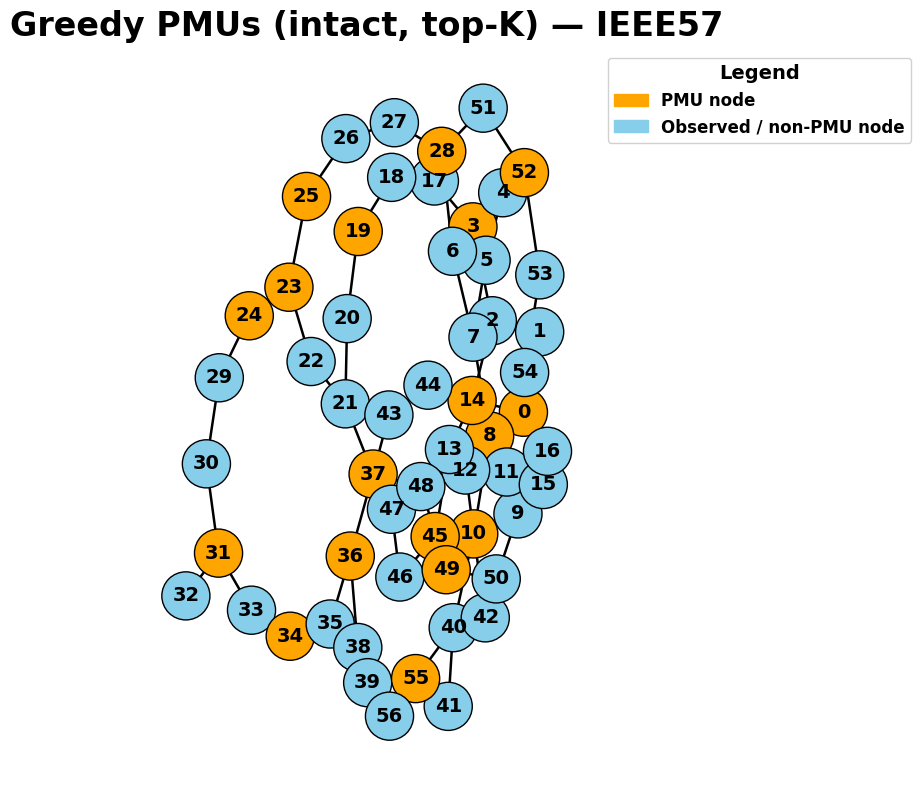

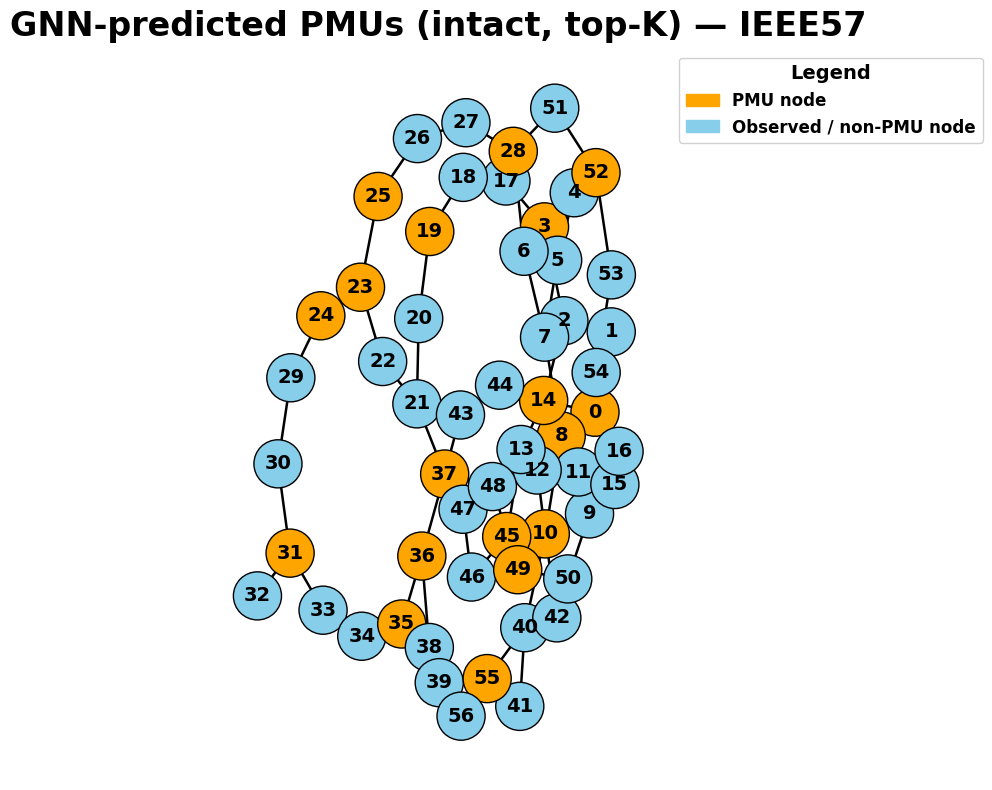

Saved PNG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023712_gnn_greedy_pmus_intact_topK_IEEE57.png
Saved SVG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023712_gnn_greedy_pmus_intact_topK_IEEE57.svg
Running Inkscape for EMF export...
Saved EMF: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023712_gnn_greedy_pmus_intact_topK_IEEE57.emf
Saved PNG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023716_gnn_gnn_pmus_intact_topK_IEEE57.png
Saved SVG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023716_gnn_gnn_pmus_intact_topK_IEEE57.svg
Running Inkscape for EMF export...
Saved EMF: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023716_gnn_gnn_pmus_intact_topK_IEEE57.emf

Saved figures to:
  greedy: D:\my_projects\pmu-placement-gnn\r

In [23]:
# %%
# ============================================
# Visual test: Greedy vs GNN on one intact graph (top-K PMUs, PNG+EMF)
# ============================================
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# --------- Coverage-aware decoding helper (define once if missing) ----------
if "gnn_select_pmus_coverage_aware" not in globals():
    @torch.no_grad()
    def gnn_select_pmus_coverage_aware(data, K, topM=80):
        data = data.to(device)
        model.eval()

        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits, dim=-1)[:, 1]

        N = int(data.num_nodes)
        M = int(min(max(1, topM), N))
        cand = torch.topk(probs, k=M, largest=True).indices.cpu().numpy().tolist()

        neigh = [set() for _ in range(N)]
        ei = data.edge_index.cpu().numpy()
        for u, v in ei.T:
            u = int(u); v = int(v)
            if u == v:
                continue
            neigh[u].add(v)
            neigh[v].add(u)

        cover_sets = {c: (set([c]) | neigh[c]) for c in cand}
        probs_cpu = probs.detach().cpu().numpy()

        chosen = []
        covered = set()
        remaining = set(cand)

        for _ in range(int(K)):
            best = None
            best_gain = -1
            best_prob = -1.0
            for c in remaining:
                gain = len(cover_sets[c] - covered)
                p = float(probs_cpu[c])
                if (gain > best_gain) or (gain == best_gain and p > best_prob):
                    best_gain = gain
                    best_prob = p
                    best = c
            if best is None:
                break
            chosen.append(best)
            covered |= cover_sets[best]
            remaining.remove(best)

        return chosen

# ---------------------------------------------------------------------------

def pyg_to_nx_graph(data):
    """Convert a PyG Data object (edge_index) to a NetworkX Graph."""
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    edge_index = data.edge_index.cpu().numpy()
    for u, v in edge_index.T:
        u = int(u)
        v = int(v)
        if u == v:
            continue
        G.add_edge(u, v)
    return G

def observed_nodes_simple(G, pmu_nodes):
    obs = set(pmu_nodes)
    for n in pmu_nodes:
        obs.update(G.neighbors(n))
    return obs

def greedy_pmu_placement_simple(G):
    """Greedy OPP on a pure graph (no weights)."""
    all_nodes = set(G.nodes())
    pmus = []
    observed = set()
    while observed != all_nodes:
        best_node, best_gain = None, -1
        for n in all_nodes - set(pmus):
            gain = len(observed_nodes_simple(G, [n]) - observed)
            if gain > best_gain:
                best_gain, best_node = gain, n
        pmus.append(best_node)
        observed.update(observed_nodes_simple(G, [best_node]))
    return pmus

def plot_pmus(G, pmu_nodes, title, failed_edge=None):
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines

    pmu_nodes = set(pmu_nodes)
    pos = nx.kamada_kawai_layout(G)
    node_size = 1200

    pmu_color   = "orange"
    other_color = "skyblue"

    colors = [pmu_color if n in pmu_nodes else other_color for n in G.nodes()]

    fig, ax = plt.subplots(figsize=(10, 8))

    nx.draw(
        G, pos,
        with_labels=True,
        node_color=colors,
        node_size=node_size,
        edgecolors="black",
        edge_color="black",
        width=1.8,
        font_size=14,
        font_weight="bold",
        ax=ax,
    )

    failed_drawn = False
    if failed_edge is not None:
        u, v = failed_edge
        if (u in pos) and (v in pos):
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            ax.plot([x1, x2], [y1, y2],
                    linewidth=6, color="red", alpha=0.9, zorder=3)
            failed_drawn = True

    legend_handles = [
        mpatches.Patch(color=pmu_color,   label="PMU node"),
        mpatches.Patch(color=other_color, label="Observed / non-PMU node"),
    ]
    if failed_drawn:
        legend_handles.append(
            mlines.Line2D([], [], color="red", linewidth=4, label="Failed branch")
        )

    leg = ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.8,
        fontsize=12,
        title="Legend",
        title_fontsize=14,
        framealpha=0.9,
    )
    for t in leg.get_texts():
        t.set_fontweight("bold")
    leg.get_title().set_fontweight("bold")

    # FIX: show current system name properly (IEEE118)
    system_name = os.path.basename(str(IEEE57_N1_DIR).rstrip("/\\"))
    ax.set_title(title + f" — {system_name}", fontsize=24, fontweight="bold")

    fig.tight_layout(rect=[0.0, 0.0, 0.80, 1.0])
    return fig

# ✅ REPLACED FUNCTION (6C)
@torch.no_grad()
def get_gnn_topk_pmus(data, model, k):
    # ignores "model" arg since we use global model; keeps your call sites unchanged
    return sorted(gnn_select_pmus_coverage_aware(data, k, topM=max(2*k, 80)))

def find_sample_with_type(dataset, scenario_type):
    for i in range(len(dataset)):
        d = dataset[i]
        if getattr(d, "scenario_type", None) == scenario_type:
            return i, d
    return None, None

# ---------- Pick one intact sample (prefer val, then train, then full) ----------
intact_idx, intact = find_sample_with_type(val_dataset, "intact")
source_intact = "val_dataset"

if intact is None:
    intact_idx, intact = find_sample_with_type(train_dataset, "intact")
    source_intact = "train_dataset"
if intact is None:
    intact_idx, intact = find_sample_with_type(full_dataset, "intact")
    source_intact = "full_dataset"

if intact is None:
    raise RuntimeError("No 'intact' sample found in any dataset (val/train/full).")

system_name = os.path.basename(str(IEEE57_N1_DIR).rstrip("/\\"))
print(f"Using intact sample index {intact_idx} from {source_intact} (scenario_type={intact.scenario_type})")

# ---------- Compute greedy & GNN PMUs (top-K) ----------
G_intact = pyg_to_nx_graph(intact)

pmus_greedy_intact = greedy_pmu_placement_simple(G_intact)
K = len(pmus_greedy_intact)

pmus_gnn_intact = get_gnn_topk_pmus(intact, model, k=K)

obs_greedy = observed_nodes_simple(G_intact, pmus_greedy_intact)
obs_gnn    = observed_nodes_simple(G_intact, pmus_gnn_intact)

cov_greedy = 100.0 * len(obs_greedy) / G_intact.number_of_nodes()
cov_gnn    = 100.0 * len(obs_gnn)    / G_intact.number_of_nodes()

print("\n--- Intact graph (top-K PMUs) ---")
print("Greedy PMUs :", pmus_greedy_intact)
print("GNN PMUs    :", pmus_gnn_intact)
print(f"Coverage greedy: {cov_greedy:.1f}%  | #PMUs = {len(pmus_greedy_intact)}")
print(f"Coverage GNN   : {cov_gnn:.1f}%  | #PMUs = {len(pmus_gnn_intact)}")

fig_greedy = plot_pmus(G_intact, pmus_greedy_intact, "Greedy PMUs (intact, top-K)")
plt.show()

fig_gnn = plot_pmus(G_intact, pmus_gnn_intact, "GNN-predicted PMUs (intact, top-K)")
plt.show()

if "save_gnn_fig" in globals():
    path_greedy = save_gnn_fig(fig_greedy, "greedy_pmus_intact_topK")
    path_gnn    = save_gnn_fig(fig_gnn,    "gnn_pmus_intact_topK")
    print("\nSaved figures to:")
    print("  greedy:", path_greedy)
    print("  gnn   :", path_gnn)
else:
    print("\n[INFO] save_gnn_fig is not defined; figures were only shown, not saved.")


Using faulted sample index 0 from val_dataset.
Could not detect a missing edge (no difference from intact?).

--- Faulted graph (top-K PMUs) ---
Greedy PMUs : [8, 37, 0, 3, 55, 23, 28, 31, 19, 45, 34, 49, 52, 10, 14, 24, 25, 36]
GNN PMUs    : [0, 14, 3, 45, 8, 49, 37, 56, 10, 55, 23, 36, 52, 53, 46, 35, 39, 22]
Coverage greedy: 100.0%  | #PMUs = 18
Coverage GNN   : 78.9%  | #PMUs = 18


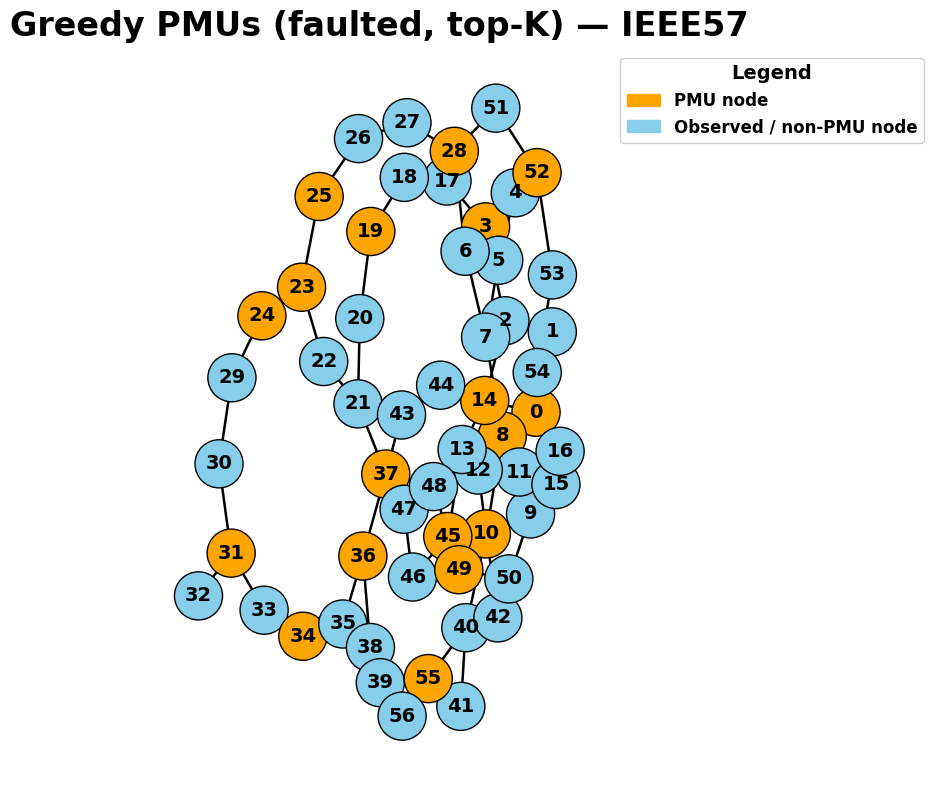

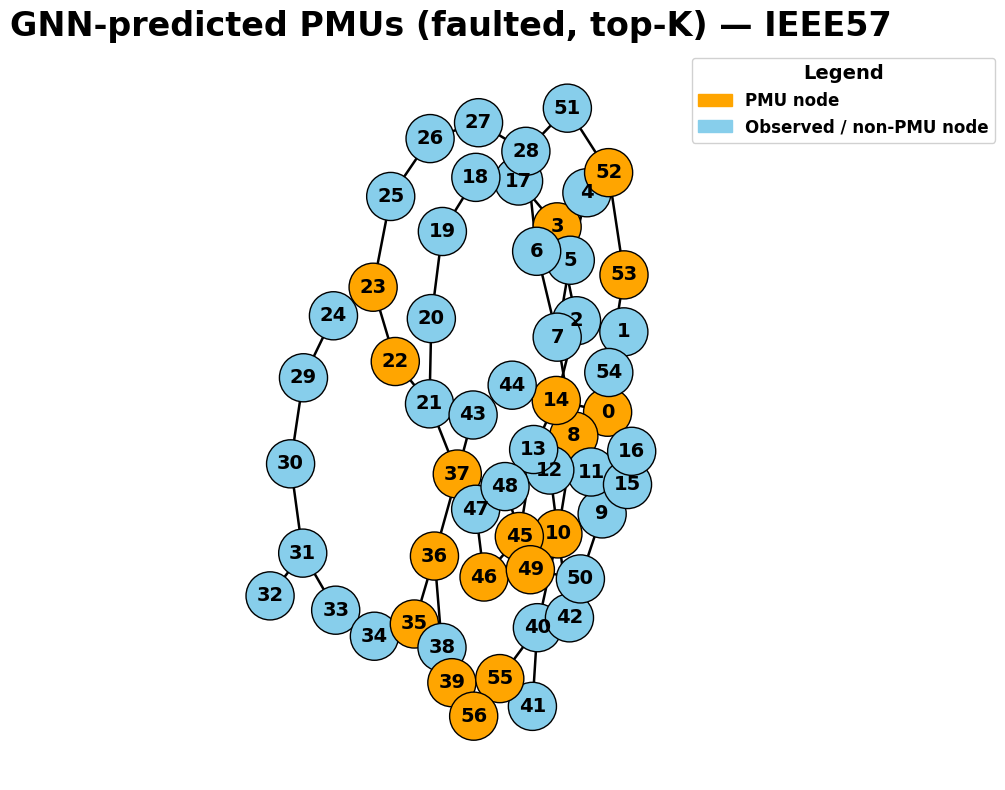

Saved PNG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023720_gnn_greedy_pmus_faulted_topK_IEEE57.png
Saved SVG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023720_gnn_greedy_pmus_faulted_topK_IEEE57.svg
Running Inkscape for EMF export...
Saved EMF: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023720_gnn_greedy_pmus_faulted_topK_IEEE57.emf
Saved PNG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023723_gnn_gnn_pmus_faulted_topK_IEEE57.png
Saved SVG: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023723_gnn_gnn_pmus_faulted_topK_IEEE57.svg
Running Inkscape for EMF export...
Saved EMF: D:\my_projects\pmu-placement-gnn\results\figures_gnn\IEEE57\GNN_20260105_023701\20260105_023723_gnn_gnn_pmus_faulted_topK_IEEE57.emf

Saved faulted figures to:
  greedy faulted: D:\my_projec

In [24]:
# %%
# ============================================
# Visual test: Greedy vs GNN on one FAULTED graph (top-K PMUs, failed branch in red)
# ============================================
import networkx as nx
import torch.nn.functional as F
import numpy as np

# We already have these from earlier cells, but just in case:
def pyg_to_nx_graph(data):
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    edge_index = data.edge_index.cpu().numpy()
    for u, v in edge_index.T:
        if u != v:
            G.add_edge(int(u), int(v))
    return G

def observed_nodes_simple(G, pmus):
    obs = set(pmus)
    for n in pmus:
        obs.update(G.neighbors(n))
    return obs

def greedy_pmu_placement_simple(G):
    all_nodes = set(G.nodes())
    pmus = []
    observed = set()
    while observed != all_nodes:
        best_node, best_gain = None, -1
        for n in all_nodes - set(pmus):
            gain = len(observed_nodes_simple(G, [n]) - observed)
            if gain > best_gain:
                best_gain, best_node = gain, n
        pmus.append(best_node)
        observed.update(observed_nodes_simple(G, [best_node]))
    return pmus

@torch.no_grad()
def gnn_topk_pmus(data, K):
    data = data.to(device)
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits, dim=-1)[:, 1]  # p(PMU)
    topk = torch.topk(probs, k=K, largest=True).indices.cpu().numpy().tolist()
    return topk

def coverage_percent(G, pmus):
    obs = observed_nodes_simple(G, pmus)
    return 100.0 * len(obs) / G.number_of_nodes()

def find_sample_with_type(dataset, scenario_type):
    for i in range(len(dataset)):
        d = dataset[i]
        if getattr(d, "scenario_type", None) == scenario_type:
            return i, d
    return None, None

# 1) Get an intact base graph (to know which edge failed)
intact_idx, intact_data = find_sample_with_type(full_dataset, "intact")
if intact_data is None:
    raise RuntimeError("No 'intact' sample found in full_dataset.")

G_intact_base = pyg_to_nx_graph(intact_data)
base_edges = {tuple(sorted(e)) for e in G_intact_base.edges()}

# 2) Pick one FAULTED sample (prefer from val_dataset)
fault_idx, fault_data = find_sample_with_type(val_dataset, "faulted")
source_fault = "val_dataset"
if fault_data is None:
    fault_idx, fault_data = find_sample_with_type(train_dataset, "faulted")
    source_fault = "train_dataset"
if fault_data is None:
    fault_idx, fault_data = find_sample_with_type(full_dataset, "faulted")
    source_fault = "full_dataset"

if fault_data is None:
    raise RuntimeError("No 'faulted' sample found in any dataset (val/train/full).")

print(f"Using faulted sample index {fault_idx} from {source_fault}.")

G_fault = pyg_to_nx_graph(fault_data)
fault_edges = {tuple(sorted(e)) for e in G_fault.edges()}

missing_edges = list(base_edges - fault_edges)
if not missing_edges:
    failed_edge = None
    print("Could not detect a missing edge (no difference from intact?).")
else:
    # For N-1 this should be exactly one
    failed_edge = missing_edges[0]
    print("Detected failed branch between nodes:", failed_edge)

# 3) Compute greedy & GNN PMUs on this faulted graph
pmus_greedy_fault = greedy_pmu_placement_simple(G_fault)
K_fault = len(pmus_greedy_fault)
pmus_gnn_fault = gnn_topk_pmus(fault_data, K_fault)

cov_greedy_fault = coverage_percent(G_fault, pmus_greedy_fault)
cov_gnn_fault    = coverage_percent(G_fault, pmus_gnn_fault)

print("\n--- Faulted graph (top-K PMUs) ---")
print("Greedy PMUs :", pmus_greedy_fault)
print("GNN PMUs    :", pmus_gnn_fault)
print(f"Coverage greedy: {cov_greedy_fault:.1f}%  | #PMUs = {len(pmus_greedy_fault)}")
print(f"Coverage GNN   : {cov_gnn_fault:.1f}%  | #PMUs = {len(pmus_gnn_fault)}")

# 4) Plot & save figures (failed branch in red on the faulted graph)
fig_greedy_faulted = plot_pmus(
    G_fault,
    pmus_greedy_fault,
    "Greedy PMUs (faulted, top-K)",
    failed_edge=failed_edge,
)
plt.show()

fig_gnn_faulted = plot_pmus(
    G_fault,
    pmus_gnn_fault,
    "GNN-predicted PMUs (faulted, top-K)",
    failed_edge=failed_edge,
)
plt.show()

# Save via helper (PNG + SVG + EMF)
if "save_gnn_fig" in globals():
    path_greedy_faulted = save_gnn_fig(fig_greedy_faulted, "greedy_pmus_faulted_topK")
    path_gnn_faulted    = save_gnn_fig(fig_gnn_faulted,    "gnn_pmus_faulted_topK")
    print("\nSaved faulted figures to:")
    print("  greedy faulted:", path_greedy_faulted)
    print("  gnn faulted   :", path_gnn_faulted)
else:
    print("\n[INFO] save_gnn_fig is not defined; faulted figures were only shown, not saved.")


In [25]:
# %%
# ============================================
# Core runtime: GNN forward on intact IEEE14
# ============================================
import time
import numpy as np
import torch

model.eval()  # inference mode

# Find one intact sample in full_dataset
intact_data = None
for i in range(len(full_dataset)):
    d = full_dataset[i]
    if getattr(d, "scenario_type", None) == "intact":
        intact_data = d
        break

if intact_data is None:
    raise RuntimeError("No intact sample with scenario_type='intact' found in full_dataset.")

intact_data = intact_data.to(device)

# Warm-up forward pass (JIT / caching / memory)
with torch.no_grad():
    _ = model(intact_data.x, intact_data.edge_index)

N = 200  # repetitions for averaging
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(N):
        _ = model(intact_data.x, intact_data.edge_index)
t1 = time.perf_counter()

avg_time_s = (t1 - t0) / N
print(f"[GNN] IEEE57 intact forward pass — avg over {N} runs: {avg_time_s*1000:.3f} ms")


[GNN] IEEE57 intact forward pass — avg over 200 runs: 2.024 ms


In [26]:
# %%
# ============================================
# PMU placement runtime ONLY: Greedy vs GNN (top-K)
# - Greedy: greedy algorithm time only
# - GNN   : forward + topK time only
# Saves CSV into METRICS_GNN_DIR
# ============================================
import os, time
import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn.functional as F

def pyg_to_nx_graph(data):
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    ei = data.edge_index.cpu().numpy()
    for u, v in ei.T:
        u = int(u); v = int(v)
        if u != v:
            G.add_edge(u, v)
    return G

def observed_nodes_simple(G, pmus):
    obs = set(pmus)
    for n in pmus:
        obs.update(G.neighbors(n))
    return obs

def greedy_pmu_placement_simple(G):
    all_nodes = set(G.nodes())
    pmus = []
    observed = set()
    while observed != all_nodes:
        best_node, best_gain = None, -1
        for n in all_nodes - set(pmus):
            gain = len(observed_nodes_simple(G, [n]) - observed)
            if gain > best_gain:
                best_gain, best_node = gain, n
        pmus.append(best_node)
        observed.update(observed_nodes_simple(G, [best_node]))
    return pmus

@torch.no_grad()
def gnn_forward_topk_time_ms(data, K):
    data = data.to(device)
    t0 = time.perf_counter()
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits, dim=-1)[:, 1]
    _ = torch.topk(probs, k=K, largest=True).indices
    t1 = time.perf_counter()
    return (t1 - t0) * 1000.0

# ---- choose dataset ----
eval_dataset = val_dataset  # or full_dataset / train_dataset

model.eval()

greedy_ms, gnn_ms, K_list, types_list = [], [], [], []

for i in range(len(eval_dataset)):
    data = eval_dataset[i]
    types_list.append(getattr(data, "scenario_type", "unknown"))

    # build NX graph outside timing
    G = pyg_to_nx_graph(data)

    # greedy placement time only
    t0 = time.perf_counter()
    pmus_greedy = greedy_pmu_placement_simple(G)
    t1 = time.perf_counter()
    t_greedy = (t1 - t0) * 1000.0

    K = len(pmus_greedy)

    # GNN placement time only (forward + topK)
    t_gnn = gnn_forward_topk_time_ms(data, K)

    greedy_ms.append(t_greedy)
    gnn_ms.append(t_gnn)
    K_list.append(K)

    print(f"Graph {i:02d} | type={types_list[-1]:7s} | K={K:2d} | "
          f"Greedy={t_greedy:7.3f} ms | GNN={t_gnn:7.3f} ms")

df_time = pd.DataFrame([{
    "system": SYSTEM_NAME,
    "gnn_run_id": GNN_RUN_ID,
    "dataset_used": "val_dataset",
    "num_graphs": int(len(eval_dataset)),
    "num_buses": int(eval_dataset[0].num_nodes),
    "avg_K": float(np.mean(K_list)),
    "greedy_pmu_placement_ms_per_graph": float(np.mean(greedy_ms)),
    "gnn_forward_topk_ms_per_graph": float(np.mean(gnn_ms)),
    "num_intact_in_eval": int(sum(t == "intact" for t in types_list)),
    "num_faulted_in_eval": int(sum(t == "faulted" for t in types_list)),
}])

display(df_time)

out_dir = METRICS_GNN_DIR if "METRICS_GNN_DIR" in globals() else os.path.join(RESULTS_ROOT, "metrics_gnn")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"pmu_placement_runtime_{SYSTEM_NAME}_{GNN_RUN_ID}.csv")

safe_to_csv(df_time, out_path, index=False)
print("Saved:", out_path)


Graph 00 | type=faulted | K=18 | Greedy=  1.563 ms | GNN=  3.423 ms
Graph 01 | type=faulted | K=19 | Greedy=  1.808 ms | GNN=  3.025 ms
Graph 02 | type=faulted | K=18 | Greedy=  1.575 ms | GNN=  2.669 ms
Graph 03 | type=faulted | K=18 | Greedy=  1.324 ms | GNN=  2.229 ms
Graph 04 | type=faulted | K=18 | Greedy=  1.465 ms | GNN=  2.962 ms
Graph 05 | type=faulted | K=18 | Greedy=  1.310 ms | GNN=  2.257 ms
Graph 06 | type=faulted | K=18 | Greedy=  1.334 ms | GNN=  1.808 ms
Graph 07 | type=faulted | K=18 | Greedy=  0.868 ms | GNN=  1.527 ms
Graph 08 | type=faulted | K=18 | Greedy=  0.700 ms | GNN=  2.727 ms
Graph 09 | type=faulted | K=18 | Greedy=  1.512 ms | GNN=  2.904 ms
Graph 10 | type=faulted | K=18 | Greedy=  1.710 ms | GNN=  2.520 ms
Graph 11 | type=faulted | K=18 | Greedy=  1.305 ms | GNN=  2.583 ms
Graph 12 | type=faulted | K=18 | Greedy=  1.177 ms | GNN=  1.959 ms
Graph 13 | type=faulted | K=17 | Greedy=  1.152 ms | GNN=  2.237 ms
Graph 14 | type=faulted | K=18 | Greedy=  1.334 

,system,gnn_run_id,dataset_used,num_graphs,num_buses,avg_K,greedy_pmu_placement_ms_per_graph,gnn_forward_topk_ms_per_graph,num_intact_in_eval,num_faulted_in_eval
0,IEEE57,GNN_20260105_023354,val_dataset,16,57,18.0625,1.332631,2.422963,0,16


Saved CSV: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354\pmu_placement_runtime_IEEE57_GNN_20260105_023354.csv
Saved: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354\pmu_placement_runtime_IEEE57_GNN_20260105_023354.csv


In [27]:
# %%
# ============================================
# Comparison table — Average coverage & runtime: Greedy vs GNN (top-K)  + SAVE CSV
# Uses the most recent df_cov + df_time from above cells (or loads latest matching files)
# ============================================
import os, glob
import pandas as pd

SYSTEM_NAME = globals().get("SYSTEM_NAME", None) or os.path.basename(str(IEEE118_N1_DIR).rstrip("/\\")) or "SYSTEM"
GNN_RUN_ID  = globals().get("GNN_RUN_ID", "GNN_RUN")

metrics_dir = os.path.join(RESULTS_ROOT, "metrics_gnn")

# If df_cov / df_time are not in memory, load latest files
if "df_cov" not in globals():
    cand = sorted(glob.glob(os.path.join(metrics_dir, f"gnn_coverage_metrics_{SYSTEM_NAME}_*.csv")))
    if not cand:
        raise FileNotFoundError("No gnn_coverage_metrics CSV found in metrics_gnn.")
    df_cov = pd.read_csv(cand[-1])

if "df_time" not in globals():
    cand = sorted(glob.glob(os.path.join(metrics_dir, f"pmu_placement_runtime_{SYSTEM_NAME}_*.csv")))
    if not cand:
        raise FileNotFoundError("No pmu_placement_runtime CSV found in metrics_gnn.")
    df_time = pd.read_csv(cand[-1])

row_cov  = df_cov.iloc[0]
row_time = df_time.iloc[0]

table_I = pd.DataFrame([{
    "System": SYSTEM_NAME,
    "#Buses": int(row_time["num_buses"]),
    "#Faulted graphs": int(row_cov["num_graphs"]),
    "Greedy cov. (%)": float(row_cov["avg_greedy_coverage_%"]),
    "GNN cov. (%)": float(row_cov["avg_gnn_coverage_%"]),
    "Greedy avg. time per graph (ms)": float(row_time["greedy_pmu_placement_ms_per_graph"]),
    "GNN forward+TopK time per graph (ms)": float(row_time["gnn_forward_topk_ms_per_graph"]),
}])

display(table_I)

out_path = os.path.join(metrics_dir, f"TableI_greedy_vs_gnn_{SYSTEM_NAME}_{GNN_RUN_ID}.csv")
safe_to_csv(table_I, out_path, index=False)
print("Saved:", out_path)


,System,#Buses,#Faulted graphs,Greedy cov. (%),GNN cov. (%),Greedy avg. time per graph (ms),GNN forward+TopK time per graph (ms)
0,IEEE57,57,80,100.0,99.890351,1.332631,2.422963


Saved CSV: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\TableI_greedy_vs_gnn_IEEE57_GNN_20260105_023354.csv
Saved: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\TableI_greedy_vs_gnn_IEEE57_GNN_20260105_023354.csv


In [28]:
# %%
import os, glob

print("METRICS_GNN_DIR:", METRICS_GNN_DIR)
files = sorted(glob.glob(os.path.join(METRICS_GNN_DIR, "*.csv")))
print("CSV files in this run folder:", len(files))
for f in files:
    print(" -", f)


METRICS_GNN_DIR: D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354
CSV files in this run folder: 2
 - D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354\gnn_coverage_metrics_IEEE57_GNN_20260105_023354.csv
 - D:\my_projects\pmu-placement-gnn\results\metrics_gnn\IEEE57\GNN_20260105_023354\pmu_placement_runtime_IEEE57_GNN_20260105_023354.csv
